
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df.head(5)

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las columnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

![see](https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png?raw=true)

## Laboratorio 1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



# Soluciones a los problemas. 

* Pregunta 1:

In [2]:
df_tor = df[df.isla == 'Torgersen'] # creamos un dataframe el cual solo contenga los datos de la isla Torgersen

# Sacamos el maximo y el minimo de los valores  profundidad del  pico del dataframe anterior 
max_tor = np.max(df_tor['profundidad_pico (mm)'])
min_tor = np.min(df_tor['profundidad_pico (mm)']) 

print(f'La profundidad maxima de los picos de los pinguinos de la isla de Torgersen es de {max_tor} mm')
print(f'La profundidad minima de los picos de los pinguinos de la isla de Torgersen es de {min_tor} mm')
print(f'La profundidad minima de los picos de los pinguinos de la isla de Torgersen es de {min_tor} mm')


La profundidad maxima de los picos de los pinguinos de la isla de Torgersen es de 21.5 mm
La profundidad minima de los picos de los pinguinos de la isla de Torgersen es de 15.9 mm
La profundidad minima de los picos de los pinguinos de la isla de Torgersen es de 15.9 mm


PORQUE REPITE 15.9?

* Pregunta 2:

In [3]:
arg = np.argmax(df['masa_corporal (g)'])# Extraemos la fila a la cual pertenenece el valor maximo de masa corporal 
df_maxmass = df.iloc[arg]# Extraemos toda la fila correpondiente al maximo valor de masa corporal

# Se toman los datos de interes de la fila 
isla_mm = df_maxmass.isla
especie_mm = df_maxmass.especie
genero_mm = df_maxmass.genero

print(f'La isla del  pingüino de mayor masa es {isla_mm}, su especie es {especie_mm} y su género es {genero_mm}.')

La isla del  pingüino de mayor masa es Biscoe, su especie es Gentoo y su género es Male.


* Pregunta 3:

In [ ]:
df_noge = df[np.logical_and(np.logical_not(df.especie == 'Gentoo'), df.genero == 'Male')]# Creamos un dataframe con los elementos que no inlucyan los datos tomados de la especie Gentoo
media_mas = np.mean(df_noge['masa_corporal (g)'])# Calculamos la media de las masas corporales de los datos filtrados 

print(
    f'La media de masa corporal de piguinos que no pertenencen a la especie Gentoo es de {media_mas:.2f} gramos'
    )

La media de masa corporal de piguinos que no pertenencen a la especie Gentoo es de 4010.28 gramos


* Pregunta 4:

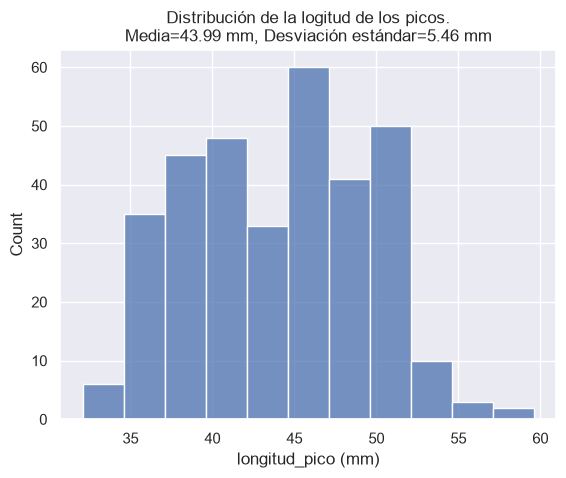

In [ ]:
# Calculamos la media y desviacion estandar de todo el dataframe original para la columna de la longitud del pico
media_lp = np.mean(df['longitud_pico (mm)'])
des_lp = np.std(df['longitud_pico (mm)'])

sns.histplot(data= df, x= 'longitud_pico (mm)')
plt.title(
    f'Distribución de la logitud de los picos.\nMedia={media_lp:.2f} mm, Desviación estándar={des_lp:.2f} mm'
    )
plt.show()

* Pregunta 5:

In [ ]:
def frec_ele (df , colum):
    """Esta función permite calcular la cantidad de elementos que se repiten en una columna del dataframe
    tomando primero una lista de los elementos unicos dentro del dataframe."""
    
    lis_uniq = df[colum].unique().tolist()
    
    print('===================================================')
    print(
        f'Para la columna {colum} tenemos los siguientes datos:'
    )
    
    for i in lis_uniq:
        cantidad = 0
        cantidad = (df[colum] == i).sum()
        print(
            f'Para {i} hay un total de {cantidad} datos'
        )

Para la columna isla tenemos los siguientes datos:
Para Torgersen hay un total de 47 datos
Para Biscoe hay un total de 163 datos
Para Dream hay un total de 123 datos
Para la columna especie tenemos los siguientes datos:
Para Adelie hay un total de 146 datos
Para Chinstrap hay un total de 68 datos
Para Gentoo hay un total de 119 datos


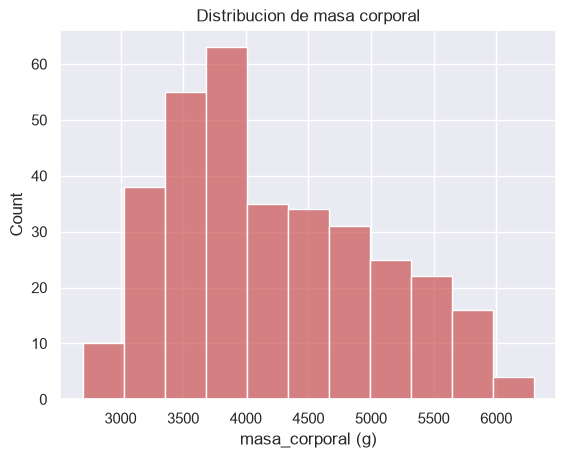

In [ ]:
# Usamos la función anteriormente creada usando las columnas de isla y especie
frec_ele(df , 'isla')
frec_ele(df , 'especie')

sns.histplot(data= df, x= 'masa_corporal (g)', color= 'indianred' )
plt.title('Distribucion de masa corporal')
plt.show()

MUY BIEN NOTA 5.0